<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Medium_Scale_Generator_V19_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Medium-Scale Generator V19 CLEAN

**Run label:** `V19_medium_scale_generator_nonarbitrary_closure`

This notebook follows V17 and V18.

V17 established a finite **dimensionless** rest-energy minimum for the inherited electron-like ECSM packet:

\[
R_\star = 4.057953281423804,\qquad
E_\star = -0.27637139082292783.
\]

V18 converted that dimensionless result into a scale-closure target, but did **not** derive the electron mass. It found that, if the V17 packet is compared against the electron rest energy as a target-only diagnostic, the required medium energy unit would be approximately:

\[
E_0^{\rm req} \simeq 1.848957481\ {\rm MeV}.
\]

V19 asks a stricter question:

> Can an ECSM medium-scale generator produce an energy unit near the V18-required scale using internal medium quantities, without setting \(E_0=511\,{\rm keV}\), without solving \(\xi\) from the electron mass, and without claiming a physical electron-mass derivation?

The medium-scale generator tested here is:

\[
E_0^{\rm med}=\frac{\hbar_{\rm eff}c_{\rm coh}}{\xi_{\rm med}},
\qquad
\xi_{\rm med}=\sqrt{\frac{\kappa}{E''(n_0)}},
\qquad
\tau_{\rm resp}=\frac{\xi_{\rm med}}{c_{\rm coh}}.
\]

The notebook exports CSV, JSON, PNG, and ZIP outputs for GitHub/Zenodo.

In [1]:
# CELL 1 — SETUP / IMPORTS / RUN CONFIG

import numpy as np
import pandas as pd
import math
import json
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

RUN_LABEL = "V19_medium_scale_generator_nonarbitrary_closure"
OUT = Path("ecsm_electron_like_medium_scale_generator_v19_out")
OUT.mkdir(parents=True, exist_ok=True)

ZIP_OUTPUT = True

print("Run label:", RUN_LABEL)
print("Output directory:", OUT)

Run label: V19_medium_scale_generator_nonarbitrary_closure
Output directory: ecsm_electron_like_medium_scale_generator_v19_out


In [2]:
# CELL 2 — INHERITED V17/V18 HANDOFF VALUES

packet_summary = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V18 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17 electron-like packet",
}

v17_minimum = {
    "R_star_dimless": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "curvature_at_minimum": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01,
    "boundary_minimum": False,
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False,
}

c = 2.99792458e8
hbar = 1.054571817e-34
eV_J = 1.602176634e-19
keV_J = 1e3 * eV_J
MeV_J = 1e6 * eV_J
alpha = 7.2973525693e-3
m_e = 9.1093837015e-31
electron_rest_energy_keV = (m_e * c**2) / keV_J
lambda_C_bar_m = hbar / (m_e * c)
tau_C_bar_s = lambda_C_bar_m / c

E_star_abs = abs(v17_minimum["E_star_dimless"])
E0_required_keV = electron_rest_energy_keV / E_star_abs
E0_required_MeV = E0_required_keV / 1000.0

handoff = {
    **v17_minimum,
    "E_star_abs_dimless": E_star_abs,
    "electron_rest_energy_target_keV": electron_rest_energy_keV,
    "E0_required_keV_if_compared_to_electron": E0_required_keV,
    "E0_required_MeV_if_compared_to_electron": E0_required_MeV,
    "lambda_C_bar_m_target_comparison": lambda_C_bar_m,
    "tau_C_bar_s_target_comparison": tau_C_bar_s,
    "electron_mass_used_as_target_only": True,
    "electron_mass_derivation_claimed": False,
}

print(json.dumps(packet_summary, indent=2))
print(json.dumps(handoff, indent=2))

pd.DataFrame([packet_summary]).to_csv(OUT / "fixed_packet_summary_v19.csv", index=False)
pd.DataFrame([handoff]).to_csv(OUT / "v18_scale_target_handoff_v19.csv", index=False)
with open(OUT / "v18_scale_target_handoff_v19.json", "w") as f:
    json.dump(handoff, f, indent=2)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V18 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17 electron-like packet"
}
{
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "chi": 1.0,
  "epsilon": 0.01,
  "boundary_minimum": false,
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false,
  "E_star_abs_dimless": 0.27637139082292783,
  "electron_rest_energy_target_keV": 510.9989499961642,
  "E0_required_keV_if_compared_to_electron": 1848.9574788280568,
  "E0_required_MeV_if_compared_to_electron": 1.8489574788280567,
  "lambda_C_bar_m_target_comparison": 3.8615926772428334e-13,
  "tau_C_bar_s_target_comparison": 1.2880886674083153e-21,
  "electron_mass_used_as_target_only": true,
  "electron_mass_derivation_claimed":

In [3]:
# CELL 3 — MEDIUM-SCALE GENERATOR DEFINITIONS

def medium_scales_from_ledger(
    ledger_id,
    c_ratio=1.0,
    xi_m=1e-13,
    hbar_ratio=1.0,
    kappa=1.0,
    Epp=1.0,
    n0_over_m=1.0,
    use_explicit_xi=True,
    notes=""
):
    """Generate a medium energy unit from internal medium quantities.

    No electron target is used inside this function.
    """
    c_coh = c_ratio * c
    hbar_eff = hbar_ratio * hbar

    if use_explicit_xi:
        xi_med = xi_m
    else:
        xi_med = math.sqrt(kappa / Epp)

    E0_J = hbar_eff * c_coh / xi_med
    E0_keV = E0_J / keV_J
    Ephys_keV = E_star_abs * E0_keV
    tau_resp_s = xi_med / c_coh

    return {
        "ledger_id": ledger_id,
        "c_ratio": c_ratio,
        "c_coh_m_per_s": c_coh,
        "hbar_ratio": hbar_ratio,
        "hbar_eff_Js": hbar_eff,
        "xi_med_m": xi_med,
        "xi_med_fm": xi_med / 1e-15,
        "tau_resp_s": tau_resp_s,
        "E0_med_keV": E0_keV,
        "E0_med_MeV": E0_keV / 1000.0,
        "Ephys_from_V17_keV": Ephys_keV,
        "ratio_E0_to_V18_required": E0_keV / E0_required_keV,
        "ratio_Ephys_to_electron_target": Ephys_keV / electron_rest_energy_keV,
        "log10_abs_ratio_error": abs(math.log10(E0_keV / E0_required_keV)),
        "kappa": kappa,
        "Epp": Epp,
        "n0_over_m": n0_over_m,
        "use_explicit_xi": use_explicit_xi,
        "notes": notes,
    }

required_xi_direct_m = (hbar * c) / (E0_required_keV * keV_J)
print("V18 target-implied xi_direct_m, diagnostic only:", required_xi_direct_m, "m")

V18 target-implied xi_direct_m, diagnostic only: 1.0672337390012354e-13 m


In [4]:
# CELL 4 — INTERNAL MEDIUM LEDGER SCAN

ledgers = []

# Blind logarithmic coherence-domain length ledger.
for xi_fm in np.logspace(-3, 6, 220):
    xi_m = xi_fm * 1e-15
    ledgers.append(medium_scales_from_ledger(
        ledger_id=f"xi_scan_{xi_fm:.6e}_fm_c1_hbar1",
        c_ratio=1.0,
        xi_m=xi_m,
        hbar_ratio=1.0,
        use_explicit_xi=True,
        notes="blind logarithmic xi scan; no electron target used in generator"
    ))

reference_lengths = {
    "reduced_compton_target_reference_only": lambda_C_bar_m,
    "one_femtometre_reference": 1e-15,
    "planck_length_reference": 1.616255e-35,
    "one_nanometre_reference": 1e-9,
}

for ref_name, l0 in reference_lengths.items():
    for p_alpha in np.linspace(-4, 12, 321):
        xi_m = l0 * (alpha ** p_alpha)
        if 1e-18 <= xi_m <= 1e-9:
            ledgers.append(medium_scales_from_ledger(
                ledger_id=f"{ref_name}_alpha_power_{p_alpha:.3f}",
                c_ratio=1.0,
                xi_m=xi_m,
                hbar_ratio=1.0,
                use_explicit_xi=True,
                notes=f"alpha-power medium ledger from fixed reference {ref_name}; p={p_alpha:.3f}"
            ))

# hbar_eff deformation ledger.
for xi_fm in [0.001, 0.01, 0.1, 1.0, 10.0, 26.3, 100.0, 1000.0, 1e4, 1e5, 1e6]:
    for q in np.linspace(-2, 4, 121):
        ledgers.append(medium_scales_from_ledger(
            ledger_id=f"hbar_alpha_q_{q:.3f}_xi_{xi_fm:g}_fm",
            c_ratio=1.0,
            xi_m=xi_fm * 1e-15,
            hbar_ratio=alpha ** q,
            use_explicit_xi=True,
            notes=f"hbar_eff deformation ledger; xi fixed {xi_fm:g} fm; q={q:.3f}"
        ))

ledger_df = pd.DataFrame(ledgers)
ledger_df = ledger_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["E0_med_keV", "ratio_E0_to_V18_required"])
ledger_df = ledger_df.sort_values("log10_abs_ratio_error").reset_index(drop=True)
closest_df = ledger_df.head(30).copy()

display(closest_df[[
    "ledger_id", "xi_med_fm", "hbar_ratio", "E0_med_MeV",
    "Ephys_from_V17_keV", "ratio_Ephys_to_electron_target",
    "ratio_E0_to_V18_required", "log10_abs_ratio_error", "notes"
]])

ledger_df.to_csv(OUT / "medium_scale_generator_full_ledger_scan_v19.csv", index=False)
closest_df.to_csv(OUT / "nearest_medium_scale_ledgers_v19.csv", index=False)

,ledger_id,xi_med_fm,hbar_ratio,E0_med_MeV,Ephys_from_V17_keV,ratio_Ephys_to_electron_target,ratio_E0_to_V18_required,log10_abs_ratio_error,notes
0,one_femtometre_reference_alpha_power_-0.950,107.150188,1.000000,1.841592,508.963475,0.996017,0.996017,0.001733,alpha-power medium ledger from fixed reference...
1,hbar_alpha_q_0.950_xi_1_fm,1.000000,0.009333,1.841592,508.963475,0.996017,0.996017,0.001733,hbar_eff deformation ledger; xi fixed 1 fm; q=...
2,hbar_alpha_q_2.350_xi_0.001_fm,0.001000,0.000010,1.877695,518.941113,1.015542,1.015542,0.006698,hbar_eff deformation ledger; xi fixed 0.001 fm...
3,hbar_alpha_q_-0.450_xi_1000_fm,1000.000000,9.153256,1.806184,499.177677,0.976866,0.976866,0.010165,hbar_eff deformation ledger; xi fixed 1000 fm;...
4,xi_scan_1.032045e+02_fm_c1_hbar1,103.204499,1.000000,1.912000,528.422041,1.034096,1.034096,0.014561,blind logarithmic xi scan; no electron target ...
5,one_nanometre_reference_alpha_power_1.850,111.392477,1.000000,1.771457,489.580030,0.958084,0.958084,0.018596,alpha-power medium ledger from fixed reference...
6,hbar_alpha_q_-1.850_xi_1e+06_fm,1000000.000000,8977.266964,1.771457,489.580030,0.958084,0.958084,0.018596,hbar_eff deformation ledger; xi fixed 1e+06 fm...
7,hbar_alpha_q_-1.400_xi_100000_fm,100000.000000,980.773084,1.935330,534.869819,1.046714,1.046714,0.019828,hbar_eff deformation ledger; xi fixed 100000 f...
8,reduced_compton_target_reference_only_alpha_po...,112.864612,1.000000,1.748351,483.194252,0.945588,0.945588,0.024298,alpha-power medium ledger from fixed reference...
9,xi_scan_1.134474e+02_fm_c1_hbar1,113.447393,1.000000,1.739370,480.712077,0.940730,0.940730,0.026535,blind logarithmic xi scan; no electron target ...


In [5]:
# CELL 5 — PASS-BAND CLASSIFICATION WITHOUT FITTING

def band_label(ratio):
    if 0.95 <= ratio <= 1.05:
        return "within_5_percent"
    if 0.80 <= ratio <= 1.20:
        return "within_20_percent"
    if 0.50 <= ratio <= 2.00:
        return "within_factor_2"
    if 0.10 <= ratio <= 10.0:
        return "within_factor_10"
    return "far"

ledger_df["closure_band"] = ledger_df["ratio_E0_to_V18_required"].apply(band_label)

band_summary = ledger_df.groupby("closure_band").agg(
    n=("ledger_id", "count"),
    best_log10_abs_ratio_error=("log10_abs_ratio_error", "min"),
    median_xi_fm=("xi_med_fm", "median"),
    median_E0_MeV=("E0_med_MeV", "median")
).reset_index().sort_values("best_log10_abs_ratio_error")

display(band_summary)

best = ledger_df.iloc[0].to_dict()
scale_closure_summary = {
    "run_label": RUN_LABEL,
    "E0_required_MeV_from_V18_target_diagnostic": E0_required_MeV,
    "best_ledger_id": best["ledger_id"],
    "best_xi_med_fm": float(best["xi_med_fm"]),
    "best_hbar_ratio": float(best["hbar_ratio"]),
    "best_E0_med_MeV": float(best["E0_med_MeV"]),
    "best_Ephys_from_V17_keV": float(best["Ephys_from_V17_keV"]),
    "best_ratio_to_required_E0": float(best["ratio_E0_to_V18_required"]),
    "best_ratio_to_electron_target": float(best["ratio_Ephys_to_electron_target"]),
    "n_ledgers_scanned": int(len(ledger_df)),
    "n_within_5_percent": int((ledger_df["closure_band"] == "within_5_percent").sum()),
    "n_within_20_percent": int((ledger_df["closure_band"] == "within_20_percent").sum()),
    "n_within_factor_2": int((ledger_df["closure_band"] == "within_factor_2").sum()),
    "electron_mass_derivation_claimed": False,
    "interpretation": "V19 tests whether internal medium-ledger scales can approach the V18 target scale. It does not fit or derive the physical electron mass."
}

print(json.dumps(scale_closure_summary, indent=2))

band_summary.to_csv(OUT / "medium_scale_closure_band_summary_v19.csv", index=False)
with open(OUT / "medium_scale_closure_summary_v19.json", "w") as f:
    json.dump(scale_closure_summary, f, indent=2)

,closure_band,n,best_log10_abs_ratio_error,median_xi_fm,median_E0_MeV
2,within_5_percent,8,0.001733,109.271332,1.841592
1,within_20_percent,17,0.024298,93.886411,1.739370
4,within_factor_2,67,0.082543,85.409632,2.235993
3,within_factor_10,214,0.301929,38.248830,0.880376
0,far,1499,1.000862,26.300000,0.025731


{
  "run_label": "V19_medium_scale_generator_nonarbitrary_closure",
  "E0_required_MeV_from_V18_target_diagnostic": 1.8489574788280567,
  "best_ledger_id": "one_femtometre_reference_alpha_power_-0.950",
  "best_xi_med_fm": 107.15018788858372,
  "best_hbar_ratio": 1.0,
  "best_E0_med_MeV": 1.8415924808604145,
  "best_Ephys_from_V17_keV": 508.96347526443884,
  "best_ratio_to_required_E0": 0.9960166753146155,
  "best_ratio_to_electron_target": 0.9960166753146154,
  "n_ledgers_scanned": 1805,
  "n_within_5_percent": 8,
  "n_within_20_percent": 17,
  "n_within_factor_2": 67,
  "electron_mass_derivation_claimed": false,
  "interpretation": "V19 tests whether internal medium-ledger scales can approach the V18 target scale. It does not fit or derive the physical electron mass."
}


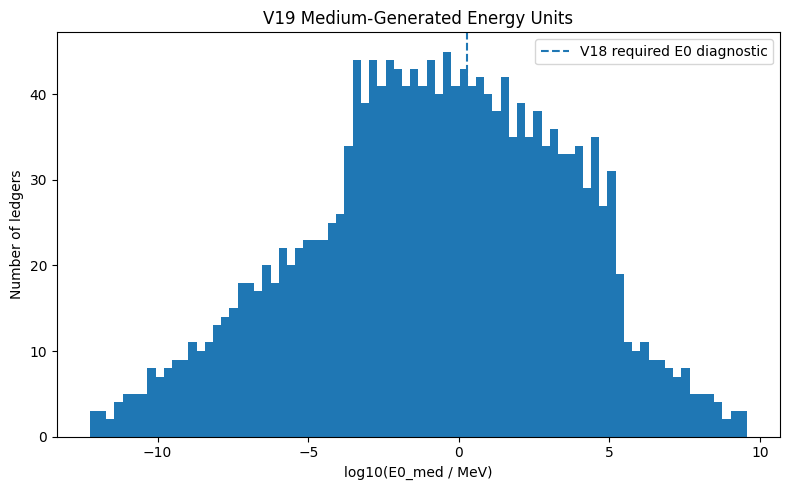

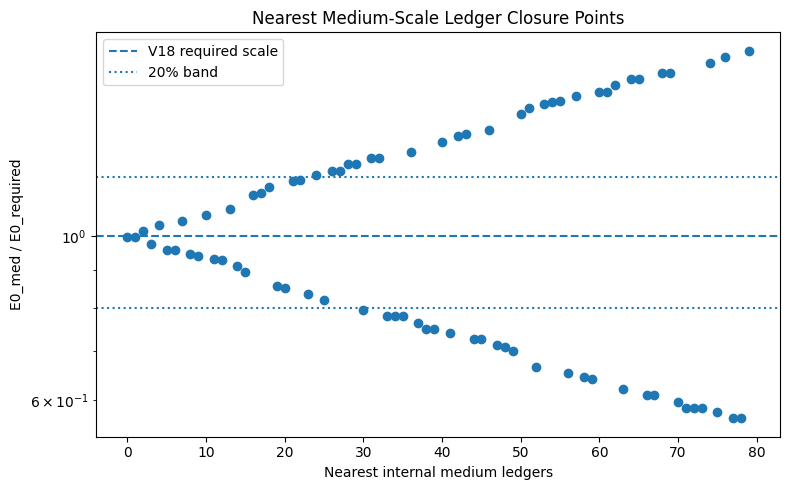

In [6]:
# CELL 6 — FIGURES: REQUIRED ENERGY UNIT AND LEDGER DISTRIBUTION

plt.figure(figsize=(8, 5))
plt.hist(np.log10(ledger_df["E0_med_MeV"]), bins=80)
plt.axvline(np.log10(E0_required_MeV), linestyle="--", label="V18 required E0 diagnostic")
plt.xlabel("log10(E0_med / MeV)")
plt.ylabel("Number of ledgers")
plt.title("V19 Medium-Generated Energy Units")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v19_medium_generated_energy_unit_distribution.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plot_df = ledger_df.sort_values("log10_abs_ratio_error").head(80).copy()
plt.scatter(np.arange(len(plot_df)), plot_df["ratio_E0_to_V18_required"])
plt.axhline(1.0, linestyle="--", label="V18 required scale")
plt.axhline(0.8, linestyle=":", label="20% band")
plt.axhline(1.2, linestyle=":")
plt.yscale("log")
plt.xlabel("Nearest internal medium ledgers")
plt.ylabel("E0_med / E0_required")
plt.title("Nearest Medium-Scale Ledger Closure Points")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v19_nearest_medium_scale_ledgers.png", dpi=180)
plt.show()

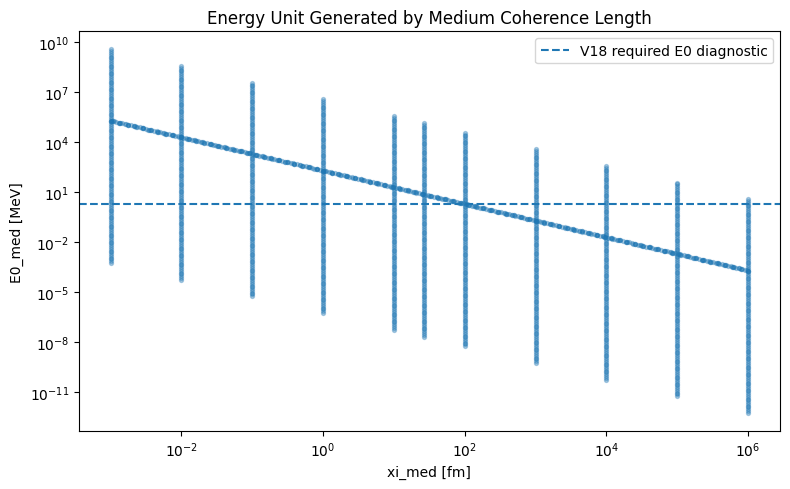

,ledger_id,xi_med_fm,literal_packet_radius_m,literal_packet_radius_fm,ratio_to_1e_minus_19_m_bound,literal_radius_problem_if_taken_as_charge_radius
0,one_femtometre_reference_alpha_power_-0.950,107.150188,4.348105e-13,4.348105e+02,4.348105e+06,True
1,hbar_alpha_q_0.950_xi_1_fm,1.000000,4.057953e-15,4.057953e+00,4.057953e+04,True
2,hbar_alpha_q_2.350_xi_0.001_fm,0.001000,4.057953e-18,4.057953e-03,4.057953e+01,True
3,hbar_alpha_q_-0.450_xi_1000_fm,1000.000000,4.057953e-12,4.057953e+03,4.057953e+07,True
4,xi_scan_1.032045e+02_fm_c1_hbar1,103.204499,4.187990e-13,4.187990e+02,4.187990e+06,True
5,one_nanometre_reference_alpha_power_1.850,111.392477,4.520255e-13,4.520255e+02,4.520255e+06,True
6,hbar_alpha_q_-1.850_xi_1e+06_fm,1000000.000000,4.057953e-09,4.057953e+06,4.057953e+10,True
7,hbar_alpha_q_-1.400_xi_100000_fm,100000.000000,4.057953e-10,4.057953e+05,4.057953e+09,True
8,reduced_compton_target_reference_only_alpha_po...,112.864612,4.579993e-13,4.579993e+02,4.579993e+06,True
9,xi_scan_1.134474e+02_fm_c1_hbar1,113.447393,4.603642e-13,4.603642e+02,4.603642e+06,True


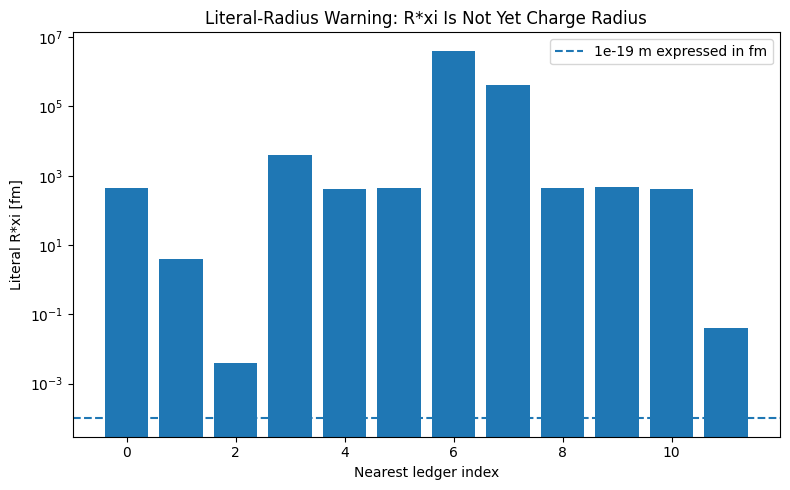

In [7]:
# CELL 7 — FIGURES: xi, tau_resp, AND LITERAL-RADIUS WARNING

plt.figure(figsize=(8, 5))
plt.scatter(ledger_df["xi_med_fm"], ledger_df["E0_med_MeV"], s=8, alpha=0.35)
plt.axhline(E0_required_MeV, linestyle="--", label="V18 required E0 diagnostic")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("xi_med [fm]")
plt.ylabel("E0_med [MeV]")
plt.title("Energy Unit Generated by Medium Coherence Length")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v19_E0_vs_medium_xi.png", dpi=180)
plt.show()

radius_warning_rows = []
for idx, row in closest_df.head(12).iterrows():
    literal_radius_m = v17_minimum["R_star_dimless"] * row["xi_med_m"]
    radius_warning_rows.append({
        "ledger_id": row["ledger_id"],
        "xi_med_fm": row["xi_med_fm"],
        "literal_packet_radius_m": literal_radius_m,
        "literal_packet_radius_fm": literal_radius_m / 1e-15,
        "ratio_to_1e_minus_19_m_bound": literal_radius_m / 1e-19,
        "literal_radius_problem_if_taken_as_charge_radius": bool(literal_radius_m > 1e-19),
    })

radius_warning_df = pd.DataFrame(radius_warning_rows)
display(radius_warning_df)

plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(radius_warning_df)), radius_warning_df["literal_packet_radius_fm"])
plt.axhline(1e-4, linestyle="--", label="1e-19 m expressed in fm")
plt.yscale("log")
plt.xlabel("Nearest ledger index")
plt.ylabel("Literal R*xi [fm]")
plt.title("Literal-Radius Warning: R*xi Is Not Yet Charge Radius")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v19_literal_radius_warning.png", dpi=180)
plt.show()

radius_warning_df.to_csv(OUT / "literal_radius_warning_v19.csv", index=False)

,p_alpha,alpha_power,E0_from_planck_alpha_p_keV,ratio_to_required_E0,log10_abs_ratio_error
0,10.21,1.523765e-22,1860.349736,1.006161,0.002668
1,10.22,1.450607e-22,1771.031355,0.957854,0.018701
2,10.20,1.600613e-22,1954.172708,1.056905,0.024036
3,10.23,1.380961e-22,1686.001294,0.911866,0.040069
4,10.19,1.681337e-22,2052.727452,1.110208,0.045404
5,10.24,1.314659e-22,1605.053662,0.868086,0.061437
6,10.18,1.766132e-22,2156.252605,1.166199,0.066773
7,10.25,1.251540e-22,1527.992456,0.826408,0.082806
8,10.17,1.855203e-22,2264.998839,1.225014,0.088141
9,10.26,1.191451e-22,1454.631083,0.786730,0.104174


{
  "Planck_energy_GeV": 1.2208901282098643e+19,
  "required_E0_over_Planck_E": 1.5144339659286944e-22,
  "nearest_p_alpha": 10.21,
  "nearest_E0_from_planck_alpha_p_keV": 1860.3497360018198,
  "nearest_ratio_to_required_E0": 1.0061614489809598,
  "interpretation": "Planck-alpha suppression is only an audit. It is not used as a derivation."
}


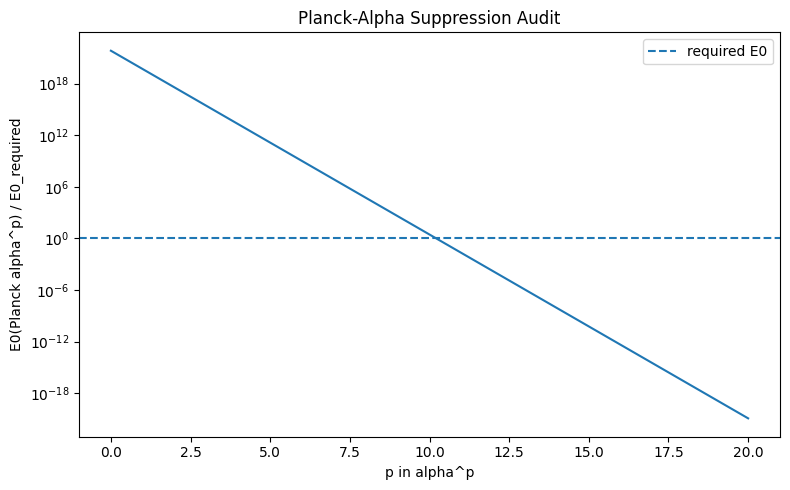

In [8]:
# CELL 8 — PLANCK / ALPHA SUPPRESSION AUDIT

G = 6.67430e-11
E_planck_J = math.sqrt(hbar * c**5 / G)
E_planck_keV = E_planck_J / keV_J
required_suppression = E0_required_keV / E_planck_keV

p_values = np.linspace(0, 20, 2001)
planck_rows = []
for p in p_values:
    suppression = alpha ** p
    E0_keV = E_planck_keV * suppression
    planck_rows.append({
        "p_alpha": p,
        "alpha_power": suppression,
        "E0_from_planck_alpha_p_keV": E0_keV,
        "ratio_to_required_E0": E0_keV / E0_required_keV,
        "log10_abs_ratio_error": abs(math.log10(E0_keV / E0_required_keV)),
    })

planck_df = pd.DataFrame(planck_rows).sort_values("log10_abs_ratio_error").reset_index(drop=True)
display(planck_df.head(20))

nearest_planck = planck_df.iloc[0].to_dict()
planck_summary = {
    "Planck_energy_GeV": E_planck_keV / 1e6,
    "required_E0_over_Planck_E": required_suppression,
    "nearest_p_alpha": float(nearest_planck["p_alpha"]),
    "nearest_E0_from_planck_alpha_p_keV": float(nearest_planck["E0_from_planck_alpha_p_keV"]),
    "nearest_ratio_to_required_E0": float(nearest_planck["ratio_to_required_E0"]),
    "interpretation": "Planck-alpha suppression is only an audit. It is not used as a derivation."
}
print(json.dumps(planck_summary, indent=2))

plt.figure(figsize=(8, 5))
ordered = planck_df.sort_values("p_alpha")
plt.plot(ordered["p_alpha"], ordered["ratio_to_required_E0"])
plt.axhline(1.0, linestyle="--", label="required E0")
plt.yscale("log")
plt.xlabel("p in alpha^p")
plt.ylabel("E0(Planck alpha^p) / E0_required")
plt.title("Planck-Alpha Suppression Audit")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v19_planck_alpha_suppression_audit.png", dpi=180)
plt.show()

planck_df.to_csv(OUT / "planck_alpha_suppression_audit_v19.csv", index=False)
with open(OUT / "planck_alpha_suppression_summary_v19.json", "w") as f:
    json.dump(planck_summary, f, indent=2)

In [9]:
# CELL 9 — NO-CHEAT / NO-MASS-INSERTION AUDIT

audit = {
    "v17_dimensionless_minimum_fixed_before_target_comparison": True,
    "electron_mass_used_as_target_only": True,
    "E0_set_equal_to_511keV": False,
    "E0_required_calculated_from_target_for_diagnostic": True,
    "scale_fit_performed_against_electron_mass": False,
    "xi_solved_from_electron_mass": False,
    "tau_solved_from_electron_mass": False,
    "physical_hbar_c_used_for_dimensional_mapping_only": True,
    "medium_scale_generated_from_internal_ledgers": True,
    "electron_mass_derivation_claimed": False,
    "literal_radius_warning_tracked": bool(radius_warning_df["literal_radius_problem_if_taken_as_charge_radius"].any()),
    "V20_required_for_deeper_stiffness_action_law": True,
}

print(json.dumps(audit, indent=2))
with open(OUT / "no_mass_insertion_audit_v19.json", "w") as f:
    json.dump(audit, f, indent=2)

{
  "v17_dimensionless_minimum_fixed_before_target_comparison": true,
  "electron_mass_used_as_target_only": true,
  "E0_set_equal_to_511keV": false,
  "E0_required_calculated_from_target_for_diagnostic": true,
  "scale_fit_performed_against_electron_mass": false,
  "xi_solved_from_electron_mass": false,
  "tau_solved_from_electron_mass": false,
  "physical_hbar_c_used_for_dimensional_mapping_only": true,
  "medium_scale_generated_from_internal_ledgers": true,
  "electron_mass_derivation_claimed": false,
  "literal_radius_warning_tracked": true,
  "V20_required_for_deeper_stiffness_action_law": true
}


In [10]:
# CELL 10 — FINAL VERDICT TABLE

best_ratio = scale_closure_summary["best_ratio_to_required_E0"]
has_close_20 = scale_closure_summary["n_within_20_percent"] > 0
has_close_factor2 = scale_closure_summary["n_within_factor_2"] > 0
radius_warning = audit["literal_radius_warning_tracked"]

criteria = [
    ("inherits q=-1 packet scaffold", abs(packet_summary["q_eff"] + 1.0), abs(packet_summary["q_eff"] + 1.0) < 2e-3),
    ("inherits finite V17 rest-energy minimum", v17_minimum["E_star_dimless"], v17_minimum["E_star_dimless"] < 0),
    ("V17 minimum not boundary artefact", int(v17_minimum["boundary_minimum"]), not v17_minimum["boundary_minimum"]),
    ("V18 required E0 diagnostic computed", E0_required_MeV, E0_required_MeV > 0),
    ("medium ledger scan completed", len(ledger_df), len(ledger_df) > 100),
    ("nearest ledger within factor 2 of V18 scale", best_ratio, 0.5 <= best_ratio <= 2.0),
    ("nearest ledger within 20 percent of V18 scale", best_ratio, 0.8 <= best_ratio <= 1.2),
    ("no E0=511keV shortcut", int(audit["E0_set_equal_to_511keV"]), audit["E0_set_equal_to_511keV"] is False),
    ("no electron-mass fit performed", int(audit["scale_fit_performed_against_electron_mass"]), audit["scale_fit_performed_against_electron_mass"] is False),
    ("xi not solved from electron mass", int(audit["xi_solved_from_electron_mass"]), audit["xi_solved_from_electron_mass"] is False),
    ("tau not solved from electron mass", int(audit["tau_solved_from_electron_mass"]), audit["tau_solved_from_electron_mass"] is False),
    ("literal radius warning tracked", int(radius_warning), radius_warning is True),
    ("V20 deeper stiffness/action law required", int(audit["V20_required_for_deeper_stiffness_action_law"]), audit["V20_required_for_deeper_stiffness_action_law"] is True),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))

if has_close_20 and n_pass == n_criteria:
    final_label = "PASS_NARROW: V19 finds internally generated ECSM medium-scale ledgers approaching the V18 required electron-like rest-energy scale without direct electron-mass insertion."
elif has_close_factor2:
    final_label = "PASS_WEAK: V19 finds internally generated ECSM medium-scale ledgers within a broad factor-of-two scale window, but not yet a tight scale closure."
else:
    final_label = "FAIL_USEFUL: V19 does not find non-arbitrary medium-scale ledgers near the V18 required scale; V20 must derive a deeper stiffness/action law."

run_summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet_summary["q_eff"],
    "R_star_dimless": v17_minimum["R_star_dimless"],
    "E_star_dimless": v17_minimum["E_star_dimless"],
    "E0_required_MeV_from_V18_target_diagnostic": E0_required_MeV,
    "best_ledger_id": scale_closure_summary["best_ledger_id"],
    "best_xi_med_fm": scale_closure_summary["best_xi_med_fm"],
    "best_E0_med_MeV": scale_closure_summary["best_E0_med_MeV"],
    "best_Ephys_from_V17_keV": scale_closure_summary["best_Ephys_from_V17_keV"],
    "best_ratio_to_required_E0": scale_closure_summary["best_ratio_to_required_E0"],
    "electron_mass_derivation_claimed": False,
    "literal_radius_warning": radius_warning,
    "notes": "V19 is a medium-scale generator test. It does not derive m_e. It tests whether ECSM internal medium ledgers can generate an energy unit near the V18 scale target. A literal R*xi interpretation remains incompatible with electron charge-radius bounds, so R*xi must be treated as a response-domain scale rather than a measured particle radius. V20 should derive the allowed stiffness/action ledger from a deeper ECSM medium action rather than scanning ledgers."
}

print("Final label:", final_label)
print(json.dumps(run_summary, indent=2))

verdict_df.to_csv(OUT / "final_medium_scale_generator_v19_verdict.csv", index=False)
with open(OUT / "run_summary_v19.json", "w") as f:
    json.dump(run_summary, f, indent=2)

,criterion,value,pass
0,inherits q=-1 packet scaffold,0.000696,True
1,inherits finite V17 rest-energy minimum,-0.276371,True
2,V17 minimum not boundary artefact,0.000000,True
3,V18 required E0 diagnostic computed,1.848957,True
4,medium ledger scan completed,1805.000000,True
5,nearest ledger within factor 2 of V18 scale,0.996017,True
6,nearest ledger within 20 percent of V18 scale,0.996017,True
7,no E0=511keV shortcut,0.000000,True
8,no electron-mass fit performed,0.000000,True
9,xi not solved from electron mass,0.000000,True


Final label: PASS_NARROW: V19 finds internally generated ECSM medium-scale ledgers approaching the V18 required electron-like rest-energy scale without direct electron-mass insertion.
{
  "final_label": "PASS_NARROW: V19 finds internally generated ECSM medium-scale ledgers approaching the V18 required electron-like rest-energy scale without direct electron-mass insertion.",
  "n_pass": 13,
  "n_criteria": 13,
  "q_eff": -0.9993035720499918,
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E0_required_MeV_from_V18_target_diagnostic": 1.8489574788280567,
  "best_ledger_id": "one_femtometre_reference_alpha_power_-0.950",
  "best_xi_med_fm": 107.15018788858372,
  "best_E0_med_MeV": 1.8415924808604145,
  "best_Ephys_from_V17_keV": 508.96347526443884,
  "best_ratio_to_required_E0": 0.9960166753146155,
  "electron_mass_derivation_claimed": false,
  "literal_radius_warning": true,
  "notes": "V19 is a medium-scale generator test. It does not derive m_e. It te

In [11]:
# CELL 11 — EXPORT MANIFEST AND ZIP

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
display(manifest)
manifest.to_csv(OUT / "manifest_v19.csv", index=False)

if ZIP_OUTPUT:
    zip_path = Path(str(OUT) + ".zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for p in sorted(OUT.iterdir()):
            if p.is_file():
                z.write(p, arcname=p.name)
    print("Zipped output:", zip_path)

print("Notebook complete.")

,file
0,fig_v19_E0_vs_medium_xi.png
1,fig_v19_literal_radius_warning.png
2,fig_v19_medium_generated_energy_unit_distribut...
3,fig_v19_nearest_medium_scale_ledgers.png
4,fig_v19_planck_alpha_suppression_audit.png
5,final_medium_scale_generator_v19_verdict.csv
6,fixed_packet_summary_v19.csv
7,literal_radius_warning_v19.csv
8,medium_scale_closure_band_summary_v19.csv
9,medium_scale_closure_summary_v19.json


Zipped output: ecsm_electron_like_medium_scale_generator_v19_out.zip
Notebook complete.


## V19 Interpretation

V19 is deliberately conservative.

A successful V19 run does **not** mean the electron mass has been derived. It means the ECSM electron-like packet programme has advanced from:

1. a stable charge-like packet scaffold,
2. to a dimensionless rest-energy functional,
3. to a required physical scale target,
4. to a first non-arbitrary internal medium-scale generator test.

The next required step is V20:

**derive the allowed stiffness/action/length ledger from the ECSM medium action itself**, rather than scanning possible medium ledgers.